# Nested Measurements

<div class="custom-button-row">
    <a 
        class="custom-button custom-download-button" href="../../notebooks/08_measurement_and_quantification/B_nested_objects.ipynb" download>
        <i class="fas fa-download"></i> Download this Notebook
    </a>
    <a
    class="custom-button custom-download-button" href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/08_measurement_and_quantification/B_nested_objects.ipynb" target="_blank">
        <img class="button-icon" src="../../_static/logo/icon-google-colab.svg" alt="Open in Colab">
        Open in Colab
    </a>
</div>

In [1]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

## Overview
In this notebook, we will address a common task in image analysis: **Relating measurements of nested objects**, I.e., measuring objects that are contained within larger scale objects and connecting those. For example, measuring the expression of a nuclear marker and relating that to cell size.

Here, we have cells that express two markers:
* A nuclear marker that is either on or off depending on cell state.
* A marker in the cytoplasm that exhibits spots.
Our question is: **Do cells that are in the nuclear *on* state exhibit more spots in the cytoplasm?**

To answer this question we will:
* Load images and masks (for cells, nuclei and spots (spots are stored in a list of coordinates))
* Use the nuclear masks to classify nuclei as *on* or *off*
* Relate this state to the corresponding cell.
* Identify which spots belong to which cells.
* Count the number of spots per cell.
* Set up a batch processing loop for all fields of view.
* Plot results and draw conclusions.

We will not be introducing new tools and will focus on using the tools we learned in the previous notebook.

## Import libraries

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
import tifffile
from bobiac_tools import overlay_labels

## Load one image and masks
First, we load one image and the corresponding label masks of the cells, nuclei, and spots.

Note that the image is a multi-channel image, therefore we will need to extract the channels that we are interested in. In this case, we are interested in the nuclear channel and the spots channel.

As before, we run through the whole analysis pipeline on this small dataset before we set up batch processing in the end.

In [3]:
# define file paths
image_path = Path(
    "../../_static/images/quant/02_nested_measurements/images/F01_837.tif"
)
mask_cell_path = Path(
    "../../_static/images/quant/02_nested_measurements/masks/F01_837w1.TIF"
)
mask_nucleus_path = Path(
    "../../_static/images/quant/02_nested_measurements/masks/F01_837w2.TIF"
)
segmentation_spots_path = Path(
    "../../_static/images/quant/02_nested_measurements/spot_lists/F01_837_spots.csv"
)

# load images and masks
image = tifffile.imread(image_path)
image_nuclear = image[2]
image_spots = image[3]

mask_cell = tifffile.imread(mask_cell_path)
mask_nucleus = tifffile.imread(mask_nucleus_path)

# remove boundary objects
mask_cell = skimage.segmentation.clear_border(mask_cell)
mask_nucleus = skimage.segmentation.clear_border(mask_nucleus)

# load segmented spots
df_spots = pd.read_csv(segmentation_spots_path)

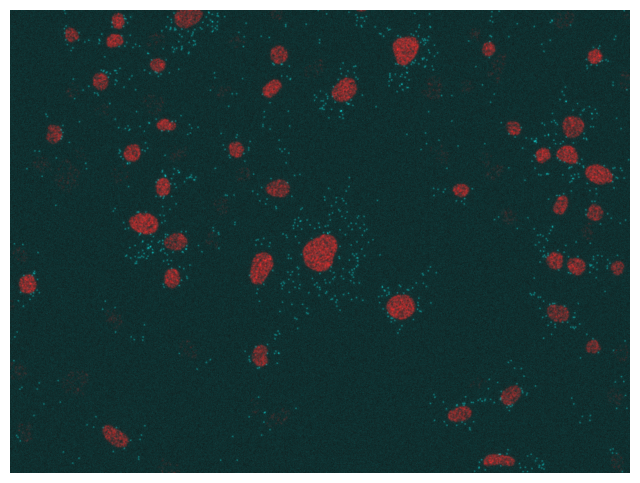

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
overlay_labels(image=[image_nuclear, image_spots])

In [5]:
print(df_spots[["y", "x"]])

         y     x
0       92   136
1       37   125
2       86   140
3       43   121
4       52   154
...    ...   ...
1173  1036  1161
1174  1026  1187
1175  1019  1197
1176  1010   509
1177  1010   472

[1178 rows x 2 columns]


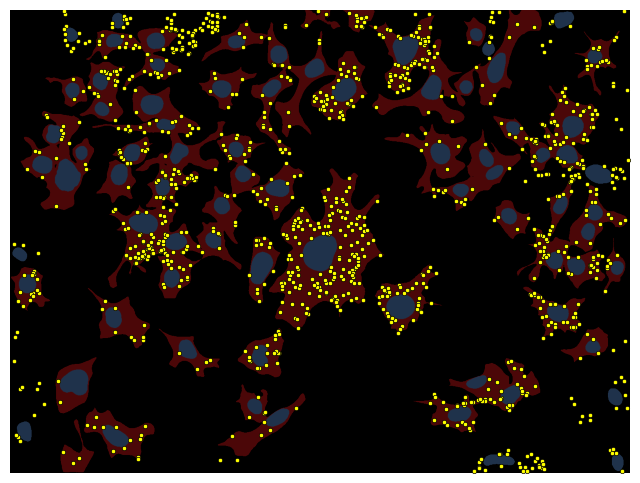

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [6]:
overlay_labels(
    label_mask=[mask_cell, mask_nucleus], coordinates=df_spots[["y", "x"]].to_numpy()
)

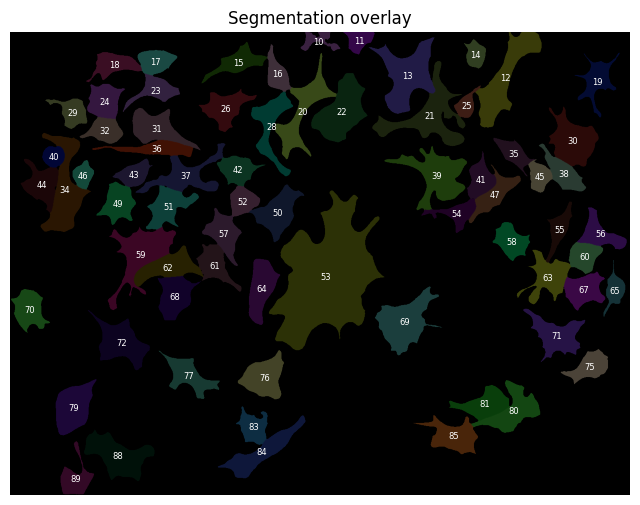

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [7]:
overlay_labels(label_mask=mask_cell)

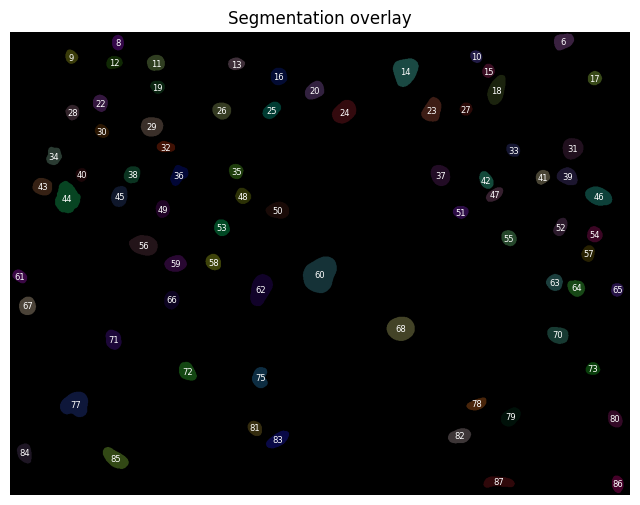

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [8]:
overlay_labels(label_mask=mask_nucleus)

## Create DataFrame for cells
First, we generate a dataframe that contains all cells. We do this using the `regionprops_table` function.

In [9]:
properties = ["area", "label"]
props = skimage.measure.regionprops_table(mask_cell, properties=properties)

df_cell = pd.DataFrame(props)
print(df_cell)

       area  label
0    1835.0     10
1    2252.0     11
2   11083.0     12
3   11811.0     13
4    2201.0     14
..      ...    ...
65   3711.0     83
66   6932.0     84
67   6111.0     85
68   9146.0     88
69   3786.0     89

[70 rows x 2 columns]


That was simple. This table now contains all labels of the cells.

## Classify nuclei
Now, we classify the each nucleus' expression levels of the nuclear marker into *on* and *off*.
For that we use the label mask of the nuclei, the nuclear expression image and the `regionpros_table` function.

### Measure properties

In [10]:
properties = ["area", "intensity_mean", "label"]
props = skimage.measure.regionprops_table(
    mask_nucleus, intensity_image=image_nuclear, properties=properties
)

df_nuc = pd.DataFrame(props)
print(df_nuc)

      area  intensity_mean  label
0   1377.0      411.344227      6
1    796.0     1915.419598      8
2    744.0     1612.961022      9
3    643.0      420.241058     10
4   1222.0      354.035188     11
..     ...             ...    ...
72  1372.0      393.518222     83
73  1219.0      403.940935     84
74  1872.0     1578.886218     85
75   868.0      422.084101     86
76  1472.0     1868.783967     87

[77 rows x 3 columns]


Let's add an `image_id` for book keeping.

In [11]:
df_nuc["image_id"] = image_path.stem
print(df_nuc)

      area  intensity_mean  label image_id
0   1377.0      411.344227      6  F01_837
1    796.0     1915.419598      8  F01_837
2    744.0     1612.961022      9  F01_837
3    643.0      420.241058     10  F01_837
4   1222.0      354.035188     11  F01_837
..     ...             ...    ...      ...
72  1372.0      393.518222     83  F01_837
73  1219.0      403.940935     84  F01_837
74  1872.0     1578.886218     85  F01_837
75   868.0      422.084101     86  F01_837
76  1472.0     1868.783967     87  F01_837

[77 rows x 4 columns]


### Classify by intensity
To understand where we should set our threshold for *on* / *off*, we can plot the intensity measurements as a histogram.

<Axes: xlabel='intensity_mean', ylabel='Count'>

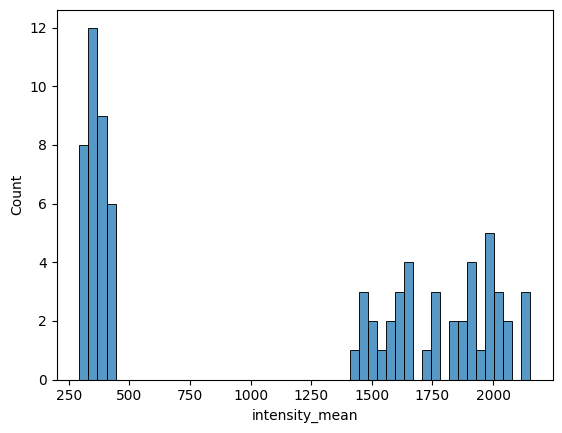

In [12]:
sns.histplot(
    data=df_nuc,
    x="intensity_mean",
    bins=50,
)

It seems like the expression is truly bimodal and 1,700 would be a good threshold. 

Now, we classify the intensity of nuclei using the `cut` function as before.

In [13]:
df_nuc["expression"] = pd.cut(
    df_nuc["intensity_mean"], bins=[0, 1000, np.inf], labels=["off", "on"]
)
print(df_nuc["expression"].unique())

['off', 'on']
Categories (2, object): ['off' < 'on']


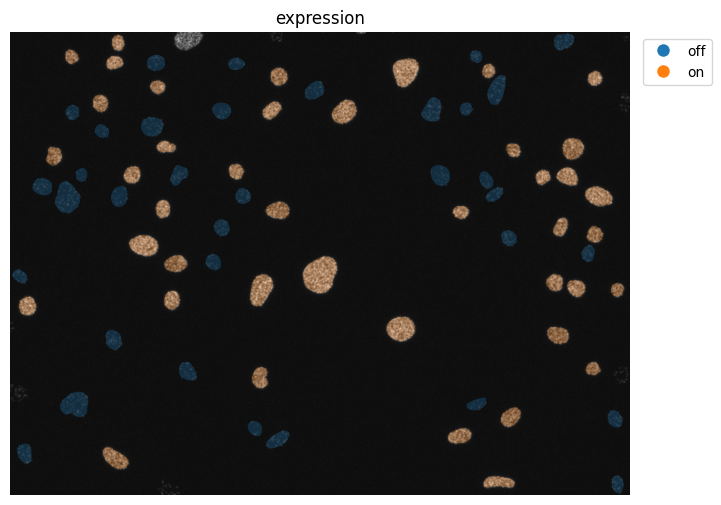

(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'expression'}>)

In [14]:
overlay_labels(
    image=image_nuclear,
    label_mask=mask_nucleus,
    df=df_nuc,
    id_col="label",
    measurement_col="expression",
)

In [15]:
print(df_nuc)

      area  intensity_mean  label image_id expression
0   1377.0      411.344227      6  F01_837        off
1    796.0     1915.419598      8  F01_837         on
2    744.0     1612.961022      9  F01_837         on
3    643.0      420.241058     10  F01_837        off
4   1222.0      354.035188     11  F01_837        off
..     ...             ...    ...      ...        ...
72  1372.0      393.518222     83  F01_837        off
73  1219.0      403.940935     84  F01_837        off
74  1872.0     1578.886218     85  F01_837         on
75   868.0      422.084101     86  F01_837        off
76  1472.0     1868.783967     87  F01_837         on

[77 rows x 5 columns]


Great! Now we have a DataFrame where each nucleus is classified as expressing or non-expressing.

## Connecting the DataFrames
We now have three DataFrames:
* `df_cell` stores information about the cells, like their area and label
* `df_nuc` stores information about the nuclei, including the expression status
* `df_spots` stores the coordinates of the spots

We want to connect information about the nucleus (*on*/*off*) with information about the spots (how many/per cell). Both of these are properties of the cell, which makes it our central object. Another way of looking at this is that the cell is the unifying object that contains both the nucleus (and its expression state) and all the dots. Dots and nuclei are not directly connected.

Practically, this means we need to create two columns in `df_cell`:
* `nuclear_expression`: that maps the expression classification of the nucleus to the cell
* `number_of_spots`: that contains how many spots exist in each cell

### Map nuclear expression
To map the expression of the nuclei to the cells, we need to know which nuclear label corresponds to which cell label. As we can see below, they are not identical.

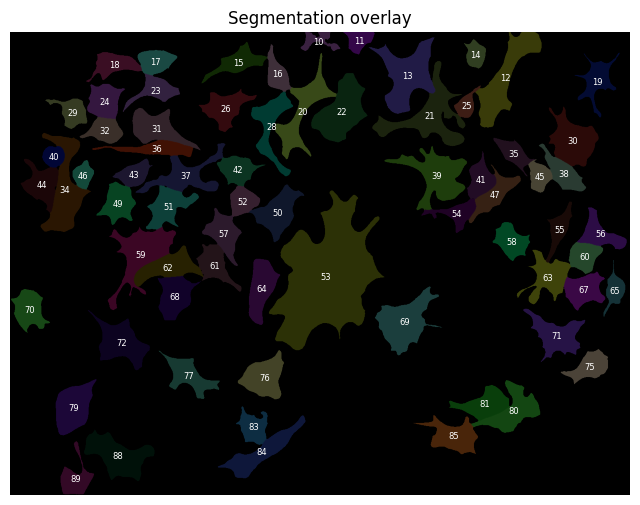

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [16]:
overlay_labels(label_mask=mask_cell)

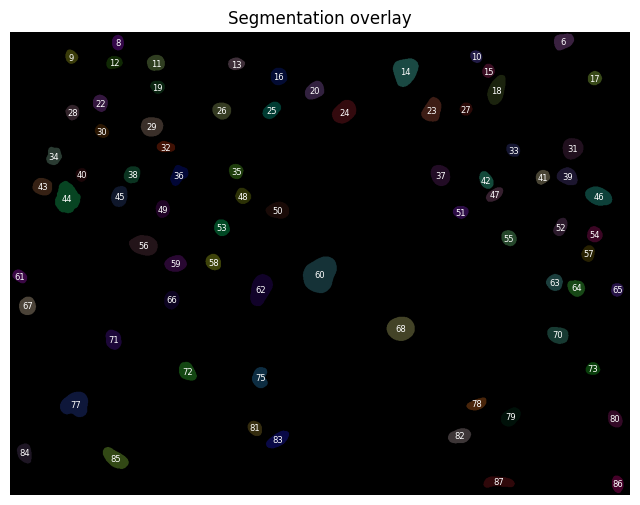

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [17]:
overlay_labels(label_mask=mask_nucleus)

We can use regionprops_table to measure identify the cell label of each nucleus.

In [18]:
properties = ["intensity_mean", "label"]
labels = skimage.measure.regionprops_table(
    mask_nucleus, intensity_image=mask_cell, properties=properties
)

df_merge = pd.DataFrame(labels)
df_merge = df_merge.rename({"intensity_mean": "label_cell"}, axis=1)
print(df_merge)

    label_cell  label
0          0.0      6
1          0.0      8
2          0.0      9
3         14.0     10
4         17.0     11
..         ...    ...
72        84.0     83
73         0.0     84
74        88.0     85
75         0.0     86
76         0.0     87

[77 rows x 2 columns]


In [19]:
df_nuc = df_nuc.merge(df_merge, on="label", how="left")
print(df_nuc)

      area  intensity_mean  label image_id expression  label_cell
0   1377.0      411.344227      6  F01_837        off         0.0
1    796.0     1915.419598      8  F01_837         on         0.0
2    744.0     1612.961022      9  F01_837         on         0.0
3    643.0      420.241058     10  F01_837        off        14.0
4   1222.0      354.035188     11  F01_837        off        17.0
..     ...             ...    ...      ...        ...         ...
72  1372.0      393.518222     83  F01_837        off        84.0
73  1219.0      403.940935     84  F01_837        off         0.0
74  1872.0     1578.886218     85  F01_837         on        88.0
75   868.0      422.084101     86  F01_837        off         0.0
76  1472.0     1868.783967     87  F01_837         on         0.0

[77 rows x 6 columns]


In [20]:
mapping = df_nuc.loc[df_nuc["label_cell"] != 0].drop_duplicates(
    "label_cell", keep=False
)[["label_cell", "expression"]]
mapping

,label_cell,expression
3,14.0,off
4,17.0,off
5,18.0,on
6,15.0,off
7,13.0,on
...,...,...
68,80.0,on
70,83.0,off
71,85.0,on
72,84.0,off


In [21]:
df_cell = df_cell.merge(
    mapping, left_on="label", right_on="label_cell", how="inner"
).drop(columns="label_cell")
print(df_cell)

       area  label expression
0   11083.0     12        off
1   11811.0     13         on
2    2201.0     14        off
3    4385.0     15        off
4    3136.0     16         on
..      ...    ...        ...
62   5343.0     81        off
63   3711.0     83        off
64   6932.0     84        off
65   6111.0     85         on
66   9146.0     88         on

[67 rows x 3 columns]


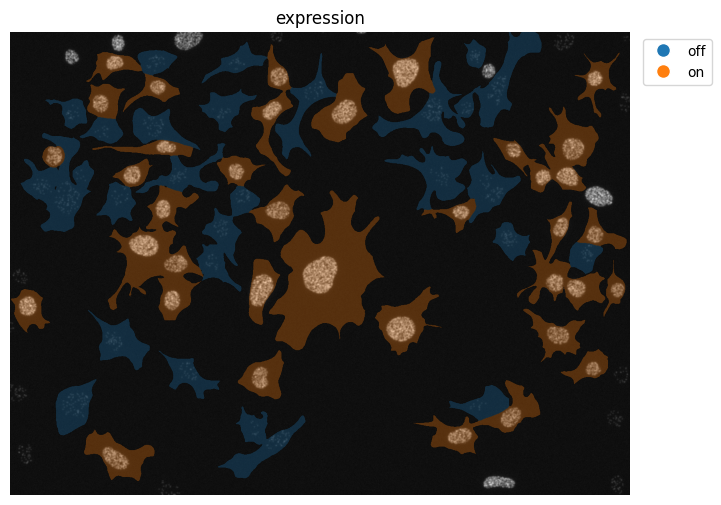

(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'expression'}>)

In [22]:
overlay_labels(
    image=image_nuclear,
    label_mask=mask_cell,
    df=df_cell,
    id_col="label",
    measurement_col="expression",
)

### Map spot count
Now we applyt the same strategy to map the number of spots to `df_cell`. 
* Per spot, identify which cell it belongs to
* Count the number of spots per cell
* Add that information to the cell dataframe

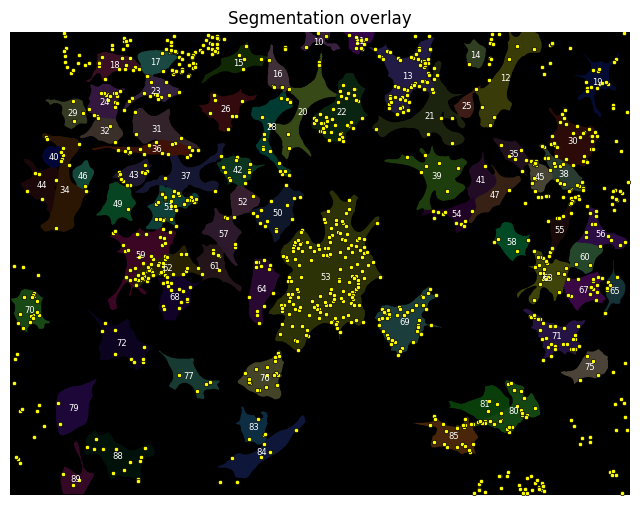

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [23]:
overlay_labels(label_mask=mask_cell, coordinates=df_spots[["y", "x"]].to_numpy())

For each spot in `df_spots` we look up the cell label in `mask_cell`. 

In [24]:
df_spots["label_cell"] = mask_cell[df_spots["y"].astype(int), df_spots["x"].astype(int)]
print(df_spots["label_cell"].unique())

[ 0 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 28 29 30 31 32 34
 35 36 37 38 39 40 41 42 43 44 45 46 47 49 50 51 52 53 54 55 56 57 58 59
 60 61 62 63 64 65 67 68 69 70 71 72 75 76 77 79 80 81 83 84 85 88 89]


Now we count the number of spots per `cell_label`.

<Axes: xlabel='label_cell', ylabel='Count'>

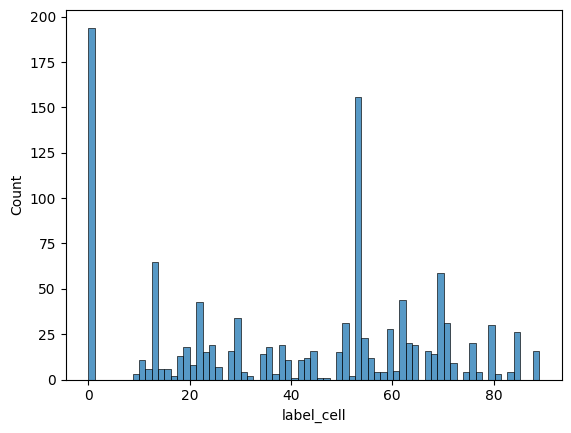

In [25]:
sns.histplot(data=df_spots, x="label_cell", bins=len(df_spots["label_cell"].unique()))

Remove spots with `cell_label == 0`. Those spots are outside of valid cells.

In [26]:
df_spots = df_spots.loc[df_spots["label_cell"] != 0]
print(df_spots)

      channel     y    x  label_cell
98          1     2  691          10
99          1    33  664          10
100         1    10  710          10
101         1    19  791          11
102         1    16  799          11
...       ...   ...  ...         ...
1143        1  1003  288          88
1144        1  1008  288          88
1145        1  1006  154          89
1146        1  1017  140          89
1147        1   992  119          89

[984 rows x 4 columns]


Now we count the spots per cell, I.e., per unique `label_cell`.

In [27]:
mapping = df_spots["label_cell"].value_counts().reset_index()
print(mapping)

    label_cell  count
0           53    156
1           13     65
2           69     44
3           62     44
4           22     43
..         ...    ...
65          46      1
66          41      1
67          25      1
68          14      1
69          47      1

[70 rows x 2 columns]


Now we merge these measurements with `df_cell`.

In [28]:
df_cell = df_cell.merge(
    mapping, left_on="label", right_on="label_cell", how="inner"
).drop(columns="label_cell")
print(df_cell)

       area  label expression  count
0   11083.0     12        off      6
1   11811.0     13         on     65
2    2201.0     14        off      1
3    4385.0     15        off      5
4    3136.0     16         on      6
..      ...    ...        ...    ...
62   5343.0     81        off      3
63   3711.0     83        off      4
64   6932.0     84        off      5
65   6111.0     85         on     21
66   9146.0     88         on     13

[67 rows x 4 columns]


<Axes: xlabel='count', ylabel='Count'>

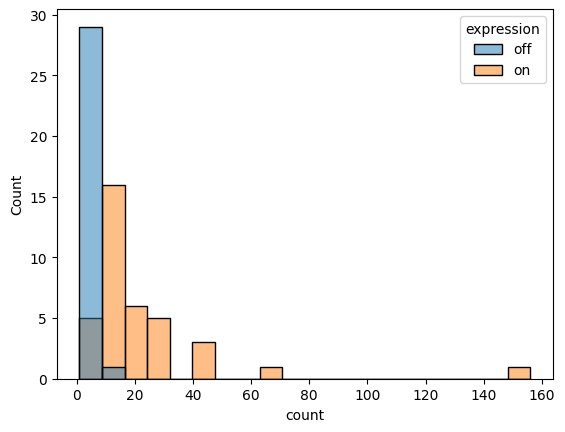

In [29]:
sns.histplot(
    data=df_cell,
    x="count",
    bins=20,
    hue="expression",
)

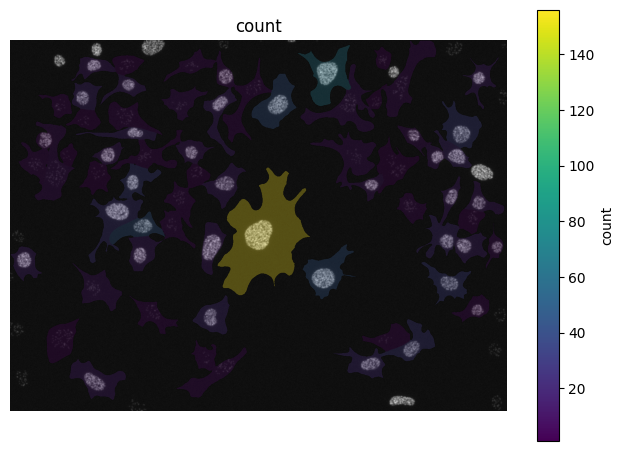

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'count'}>)

In [30]:
overlay_labels(
    image=image_nuclear,
    label_mask=mask_cell,
    df=df_cell,
    id_col="label",
    measurement_col="count",
)

## Normalisation
We can see from the overlay above that the largest cell also has the most spots. This might be a case of size and number of spots being confunding variables; larger cells have more space and therefore more spots. Let's normalise the spot count by area.

In [31]:
df_cell["spot_count_norm"] = df_cell["count"] / df_cell["area"]
print(df_cell["spot_count_norm"])

0     0.000541
1     0.005503
2     0.000454
3     0.001140
4     0.001913
        ...   
62    0.000561
63    0.001078
64    0.000721
65    0.003436
66    0.001421
Name: spot_count_norm, Length: 67, dtype: float64


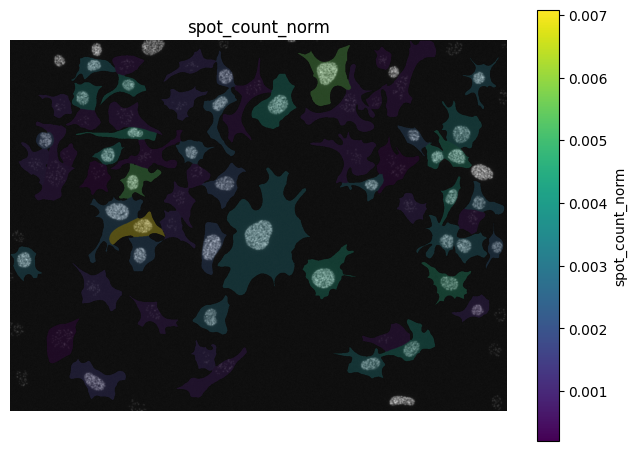

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'spot_count_norm'}>)

In [32]:
overlay_labels(
    image=image_nuclear,
    label_mask=mask_cell,
    df=df_cell,
    id_col="label",
    measurement_col="spot_count_norm",
)

<Axes: xlabel='spot_count_norm', ylabel='Count'>

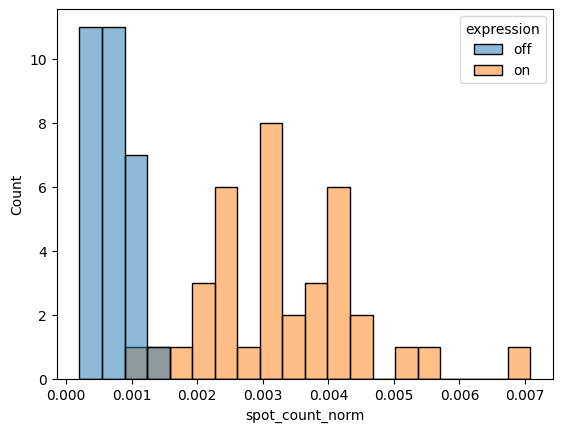

In [33]:
sns.histplot(data=df_cell, x="spot_count_norm", bins=20, hue="expression")

The picture is much clearer now.

## Batch processing
Now we set up batch processing to analyse all the images in the folder.

In [34]:
image_folder = Path("../../_static/images/quant/02_nested_measurements/images/")
mask_folder = Path("../../_static/images/quant/02_nested_measurements/masks/")
spot_folder = Path("../../_static/images/quant/02_nested_measurements/spot_lists/")

image_paths = sorted(image_folder.glob("*.tif"))

list_df = []

for image_path in image_paths:
    image_id = image_path.stem  # e.g. F01_837

    # load multi-channel image and extract nuclear channel
    image = tifffile.imread(image_path)
    image_nuclear = image[0]

    # load masks and spot coordinates
    mask_cell = tifffile.imread(mask_folder / f"{image_id}w1.TIF")
    mask_nucleus = tifffile.imread(mask_folder / f"{image_id}w2.TIF")
    df_spots = pd.read_csv(spot_folder / f"{image_id}_spots.csv")

    # remove objects touching the border
    mask_cell = skimage.segmentation.clear_border(mask_cell)
    mask_nucleus = skimage.segmentation.clear_border(mask_nucleus)

    # --- cell dataframe ---
    df_cell = pd.DataFrame(
        skimage.measure.regionprops_table(mask_cell, properties=["area", "label"])
    )

    # --- nucleus dataframe: measure and classify expression ---
    df_nuc = pd.DataFrame(
        skimage.measure.regionprops_table(
            mask_nucleus,
            intensity_image=image_nuclear,
            properties=["area", "intensity_mean", "label"],
        )
    )
    df_nuc["image_id"] = image_id
    df_nuc["expression"] = pd.cut(
        df_nuc["intensity_mean"], bins=[0, 1700, np.inf], labels=["off", "on"]
    )

    # --- map each nucleus to the cell it sits in ---
    df_merge = pd.DataFrame(
        skimage.measure.regionprops_table(
            mask_nucleus,
            intensity_image=mask_cell,
            properties=["intensity_mean", "label"],
        )
    ).rename(columns={"intensity_mean": "label_cell"})

    df_nuc = df_nuc.merge(df_merge, on="label", how="left")

    mapping_expr = df_nuc[df_nuc["label_cell"] != 0].drop_duplicates(
        "label_cell", keep=False
    )[["label_cell", "expression"]]
    df_cell = df_cell.merge(
        mapping_expr, left_on="label", right_on="label_cell", how="inner"
    ).drop(columns="label_cell")

    # --- count spots per cell ---
    df_spots["label_cell"] = mask_cell[
        df_spots["y"].astype(int), df_spots["x"].astype(int)
    ]
    df_spots = df_spots.loc[df_spots["label_cell"] != 0]
    mapping_spots = df_spots["label_cell"].value_counts().reset_index()
    df_cell = df_cell.merge(
        mapping_spots, left_on="label", right_on="label_cell", how="inner"
    ).drop(columns="label_cell")
    df_cell["spot_count_norm"] = df_cell["count"] / df_cell["area"]

    df_cell["image_id"] = image_id
    list_df.append(df_cell)

df_full = pd.concat(list_df, ignore_index=True)

In [35]:
print(df_full)

       area  label expression  count  spot_count_norm image_id
0   11083.0     12        off      6         0.000541  F01_837
1   11811.0     13        off     65         0.005503  F01_837
2    2201.0     14         on      1         0.000454  F01_837
3    4385.0     15         on      5         0.001140  F01_837
4    3136.0     16         on      6         0.001913  F01_837
..      ...    ...        ...    ...              ...      ...
62   5343.0     81        off      3         0.000561  F01_837
63   3711.0     83         on      4         0.001078  F01_837
64   6932.0     84         on      5         0.000721  F01_837
65   6111.0     85        off     21         0.003436  F01_837
66   9146.0     88         on     13         0.001421  F01_837

[67 rows x 6 columns]


In [36]:
df_plot = (
    df_full.groupby(["expression", "image_id"])[["count", "spot_count_norm"]]
    .mean()
    .reset_index()
)
df_plot

/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_35290/73150912.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_full.groupby(["expression", "image_id"])[["count", "spot_count_norm"]]


,expression,image_id,count,spot_count_norm
0,off,F01_837,19.812500,0.002175
1,on,F01_837,9.514286,0.002099


(0.0, 20.327410714285715)

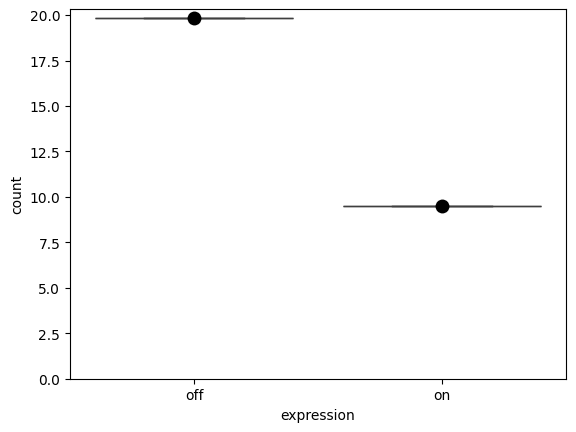

In [37]:
sns.boxplot(
    data=df_plot,
    x="expression",
    y="count",
)

sns.swarmplot(data=df_plot, x="expression", y="count", c="k", s=10)
plt.ylim(0)

(0.0, 0.0021783840977964435)

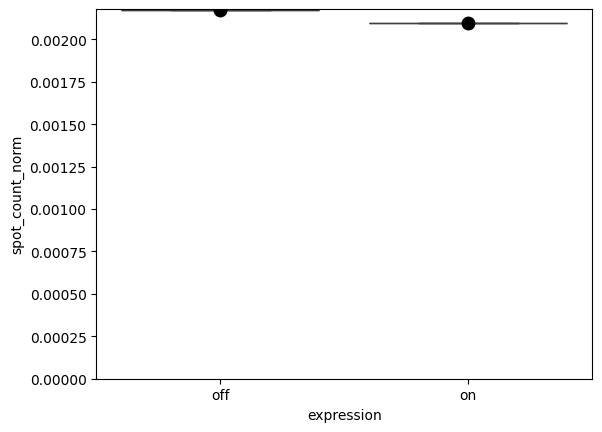

In [38]:
sns.boxplot(
    data=df_plot,
    x="expression",
    y="spot_count_norm",
)

sns.swarmplot(data=df_plot, x="expression", y="spot_count_norm", c="k", s=10)
plt.ylim(0)

## Conclusion
We successfully integrated properties of different objects with each other. Handling these sort of nested measurements is a key aspect of analysing images.